In [1]:
# within session decoding
# mean_E, correlation
# comp. of 'select'/100/250 voxels
# n1/n2_evidence_sd
# motion (framewise displacement)

import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']


In [2]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder_behav)
#df.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/all_behavior_df.csv')
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ip

In [ ]:
# save  within_ses_decodedE

from tqdm.contrib.itertools import product
from utils import get_decoding_info

subjects = df.reset_index()['subject'].unique()
sessions = [1, 2]
n_voxels_s = [100,'select'] # ? 100,200,

pred = []
for (sub, session, n_voxels) in product(subjects, sessions,n_voxels_s):
    #print(sub, session)
    pred.append(get_decoding_info(sub, session,bids_folder=bids_folder, n_voxels=n_voxels))

pred = pd.concat(pred).join(df, how='inner')
pred = pred.drop('session', axis=1)
pred

# save Es ('select' method) for comparison with across session decoding: stress-decoding_effect.ipynb
df_pred = pred.xs('select',0,'n_voxels').droplevel(axis=0, level=['mask','run'])[['E','sd']]
#df_pred.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within_ses_decodedE.csv')

In [ ]:
# select 'n_voxel" methof for further analysis
n_voxels =  'select' #'select' #'select', 100
temp = pred.xs(n_voxels, axis=0, level=4) # mutlindex in rows(=0) with level (=4 = n_voxels) that match '100'


In [20]:
# load within_ses_decodedE (of the 'select' voxel-method)
temp = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within_ses_decodedE.csv')
temp = temp.set_index(['subject']).join(group_mapping).set_index(['session','group','trial_nr'],append=True)
temp = temp.join(df['log(n1)'])
temp = temp.reset_index('group')
temp['group'] = np.where(temp['group'] == 0, 'control', 'stress')
temp = temp.set_index('group',append=True)
temp.head()


E        sd   log(n1)
subject trial_nr session run group                                
1       1        1       1   control  2.659253  0.204591  2.564949
                             control  2.659253  0.204591  3.332205
                             control  2.659253  0.204591  2.564949
                             control  2.659253  0.204591  3.332205
        2        1       1   control  2.853814  0.301871  2.079442

In [63]:
# r & sds - decodability

r = temp.groupby(['subject', 'group', 'session']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r = r.reset_index(3,drop=True) # get rid of None-index with pearson entry

sds = temp.groupby(['subject', 'group', 'session']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')

df_comb = sds.join(r['r'])
#df_comb.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within-ses-decod_r-sds.csv')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.035454,1,47,0.035454,1.266989,0.266047,0.026250,NaN
1,session,0.006963,1,47,0.006963,0.640052,0.427717,0.013435,1.0
2,Interaction,0.009505,1,47,0.009505,0.873718,0.354706,0.018250,NaN


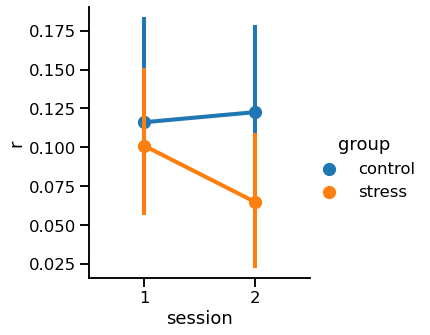

In [24]:
sns.set_context('talk')
sns.catplot(data=r.reset_index(), x='session', hue='group', y='r',kind='point',errorbar = 'se')
#plt.title(f'voxels: {n_voxels}')

pingouin.mixed_anova(data=r.reset_index(),dv='r', between='group', within='session', subject='subject')


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.050293,1,47,0.050293,2.980189,0.090858,0.059627,NaN
1,session,0.004184,1,47,0.004184,1.200345,0.278835,0.024903,1.0
2,Interaction,0.002183,1,47,0.002183,0.626316,0.432686,0.013151,NaN


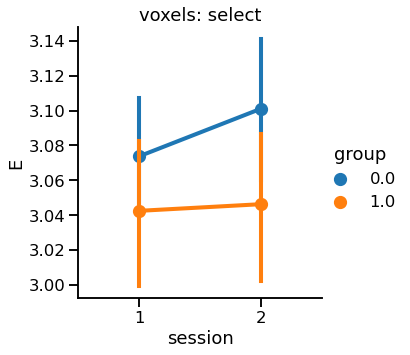

In [159]:
# mean_E
import seaborn as sns

mean_E = temp_.groupby(['subject', 'group', 'session'])[['E']].mean()
sns.catplot(data=mean_E.reset_index(), x='session', hue='group', y='E',kind='point')
plt.title(f'voxels: {n_voxels}')

# looking at 'risky_first'
#mean_E = temp_.groupby(['subject', 'group', 'session', 'risky_first'])[['E']].mean()
#f = sns.catplot(data=mean_E.reset_index(), hue='group',col = 'risky_first', x='session', y='E',kind='point',errorbar = 'se')

#mean_E = mean_E.xs(1, 0, 'session') # only onse session, hue=risky_first
#f = sns.catplot(data=mean_E.reset_index(), x='group',hue = 'risky_first',  y='E',kind='point',errorbar = 'se', palette=sns.color_palette()[4:])

pingouin.mixed_anova(data=mean_E.reset_index(),dv='E', between='group', within='session', subject='subject') #


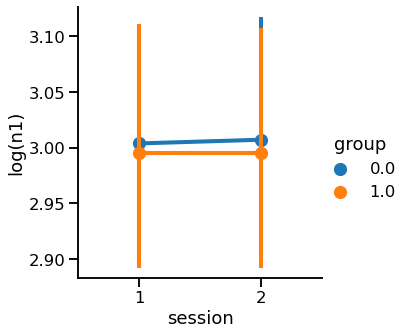

In [134]:
# objective true mean n1
mean_n1 = temp_.groupby(['subject', 'group', 'session','risky_first'])[['log(n1)']].mean()
sns.catplot(data=mean_n1.reset_index(), x='session', hue='group', y='log(n1)',kind='point') #,col = 'risky_first'

Text(0.5, 1.0, ' r=-0.46, p= 0.00081')

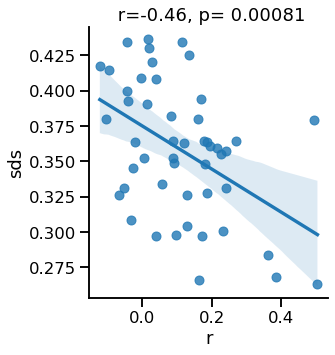

In [61]:
# correlation of SDS(E) and r(corr true log-n with E)

t = df_comb
t = t.xs(1,0,'session')
sns.lmplot(x='r',y='sds', data=t, )
cor = pingouin.corr(t['r'], t['sds'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f' r={r_}, p= {p}') # voxels: {n_voxels} \n


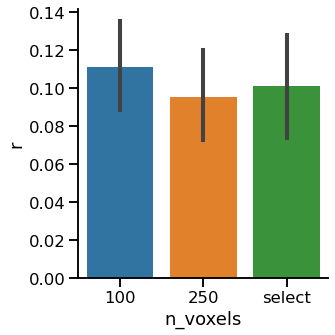

In [28]:
# comparison between different voxel-selections

import seaborn as sns
sns.set_context('talk')
t =  temp.groupby(['subject', 'n_voxels', 'session', 'group']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
sns.catplot(data=t.reset_index(), x='n_voxels', y='r', kind='bar')# , col='session', row='group'

#sns.catplot(data=r, x='group', y='r', kind='bar')


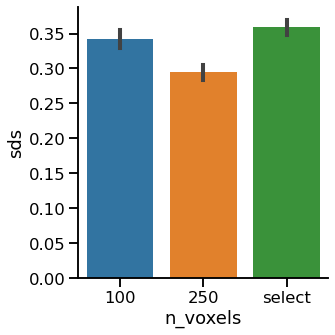

In [151]:
t =  temp.groupby(['subject', 'n_voxels']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')
sns.catplot(data=t.reset_index(), x='n_voxels', y='sds', kind='bar')# , col='session', row='group'


In [86]:
df_n1_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n1_evidence_sd.csv').set_index(['subject','session'])
df_n2_ev_sd = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_n2_evidence_sd.csv').set_index(['subject','session'])


In [139]:
n_voxels =  'select' #'select', 100
temp_ = temp.xs(n_voxels, axis=0, level=4) # mutlindex in rows(=0) with level (=4 = n_voxels) that match '100'
r = temp_.groupby(['subject', 'session']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r = r.droplevel(axis=0, level=2)
sds = temp_.groupby(['subject', 'session']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')

Text(0.5, 1.0, 'voxels: select \n r=0.03, p= 0.85615')

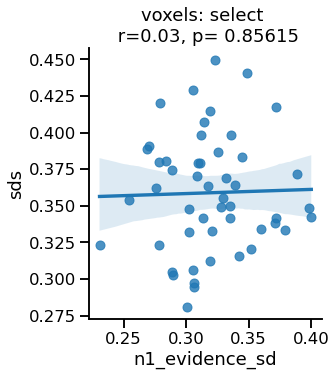

In [148]:
n= 1
t = df_n1_ev_sd.join(r[['r']]).join(sds)

t= t.groupby(['subject']).mean()
var2 = 'sds' # 'r'
sns.lmplot(x=f'n{n}_evidence_sd',y=var2, data=t, )
cor = pingouin.corr(t[f'n{n}_evidence_sd'], t[var2])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'voxels: {n_voxels} \n r={r_}, p= {p}')

In [181]:
df_motion = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_motion.csv').set_index(['subject', 'session'])

#df_motion = df_motion.join(r[['r']]).join(sds).join(group_mapping).set_index('group', append=True)


Text(0.5, 1.0, 'voxels: select \n r=0.22, p= 0.12723')

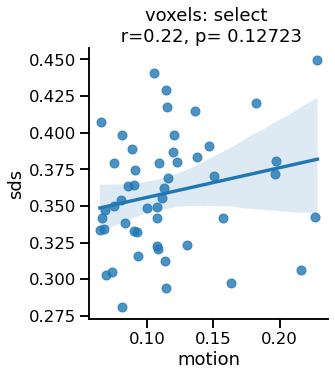

In [144]:
var2 = 'sds' # 'r'
t = df_motion
t= t.groupby(['subject']).mean()

sns.lmplot(x='motion',y=var2, data=t.reset_index()) #,col='session',row='group' 
cor = pingouin.corr(t['motion'], t[var2])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'voxels: {n_voxels} \n r={r_}, p= {p}')


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.000328,1,48,0.000328,0.088443,0.767450,0.001839,NaN
1,session,0.002689,1,48,0.002689,5.511375,0.023064,0.102994,1.0
2,Interaction,0.000043,1,48,0.000043,0.087315,0.768894,0.001816,NaN


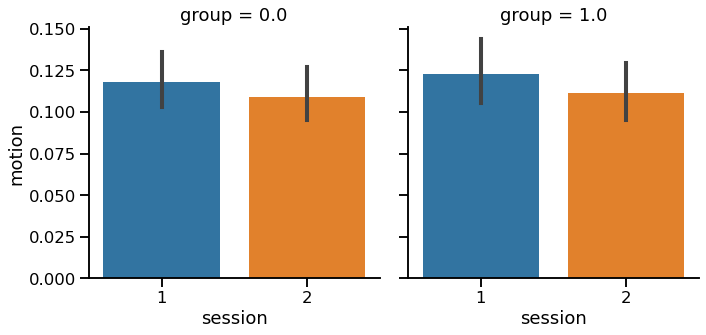

In [85]:
sns.catplot(data=t.reset_index(), x='session', y='motion', kind='bar', col='group')
pingouin.mixed_anova(data=t.reset_index(),dv='motion', between='group', within='session', subject='subject')